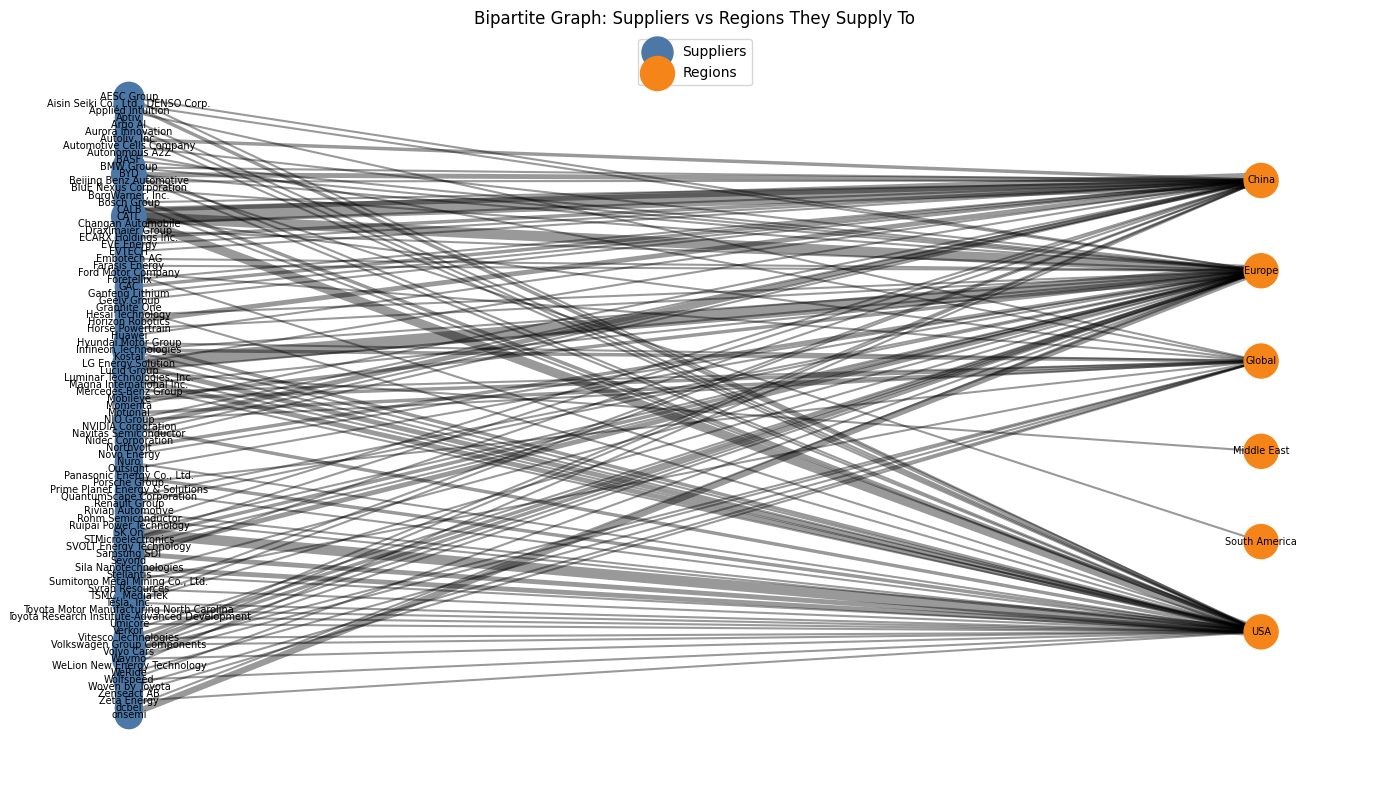

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 读取数据
df = pd.read_csv("EV_supply_graph.csv")
# 假设有列：Source（供应商）、Target（车企/工厂）、region（车企所在地区）

# 2. 统计：每个供应商在每个地区服务了多少个不同公司
group = (
    df.groupby(["Source", "region"])["Target"]
      .nunique()
      .reset_index(name="num_companies")
)

# 3. 创建二部图：一侧是 supplier，一侧是 region
B = nx.Graph()

suppliers = group["Source"].unique().tolist()
regions = group["region"].unique().tolist()

# 在二部图中标记两个集合：'bipartite' 属性用来区分左右两侧
B.add_nodes_from(suppliers, bipartite=0, type="supplier")
B.add_nodes_from(regions, bipartite=1, type="region")

# 4. 添加边：supplier ↔ region，权重为该地区服务的公司数量
for _, row in group.iterrows():
    supplier = row["Source"]
    region = row["region"]
    weight = row["num_companies"]
    B.add_edge(supplier, region, weight=weight)

# 5. 选择布局：将供应商放左侧，地区放右侧（更适合 PPT）
pos = {}

# 左侧：供应商竖排
x_sup, x_reg = 0, 1  # x 轴位置：0 = 供应商，1 = 地区
y_step_sup = 1.0 / (len(suppliers) + 1)
y_step_reg = 1.0 / (len(regions) + 1)

for i, s in enumerate(sorted(suppliers)):
    pos[s] = (x_sup, 1 - (i + 1) * y_step_sup)

for j, r in enumerate(sorted(regions)):
    pos[r] = (x_reg, 1 - (j + 1) * y_step_reg)

# 6. 准备绘图属性
supplier_nodes = [n for n, d in B.nodes(data=True) if d["type"] == "supplier"]
region_nodes = [n for n, d in B.nodes(data=True) if d["type"] == "region"]

# 节点大小：供应商根据 degree（能表示其供给范围大小）
supplier_sizes = [300 + 80 * B.degree(s) for s in supplier_nodes]
region_sizes = [600] * len(region_nodes)

# 边宽度：根据权重（供应的公司数量）
edges = B.edges(data=True)
edge_widths = [0.5 + data["weight"] for (_, _, data) in edges]

# 7. 画图
plt.figure(figsize=(14, 8))

# 供应商节点（左）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=supplier_nodes,
    node_color="#4c78a8",
    node_size=supplier_sizes,
    label="Suppliers"
)

# 地区节点（右）
nx.draw_networkx_nodes(
    B, pos,
    nodelist=region_nodes,
    node_color="#f58518",
    node_size=region_sizes,
    label="Regions"
)

# 边
nx.draw_networkx_edges(
    B, pos,
    width=edge_widths,
    alpha=0.4
)

# 标签
nx.draw_networkx_labels(B, pos, font_size=7)

plt.axis("off")
plt.title("Bipartite Graph: Suppliers vs Regions They Supply To")
plt.legend(scatterpoints=1, loc="upper center")
plt.tight_layout()
plt.show()


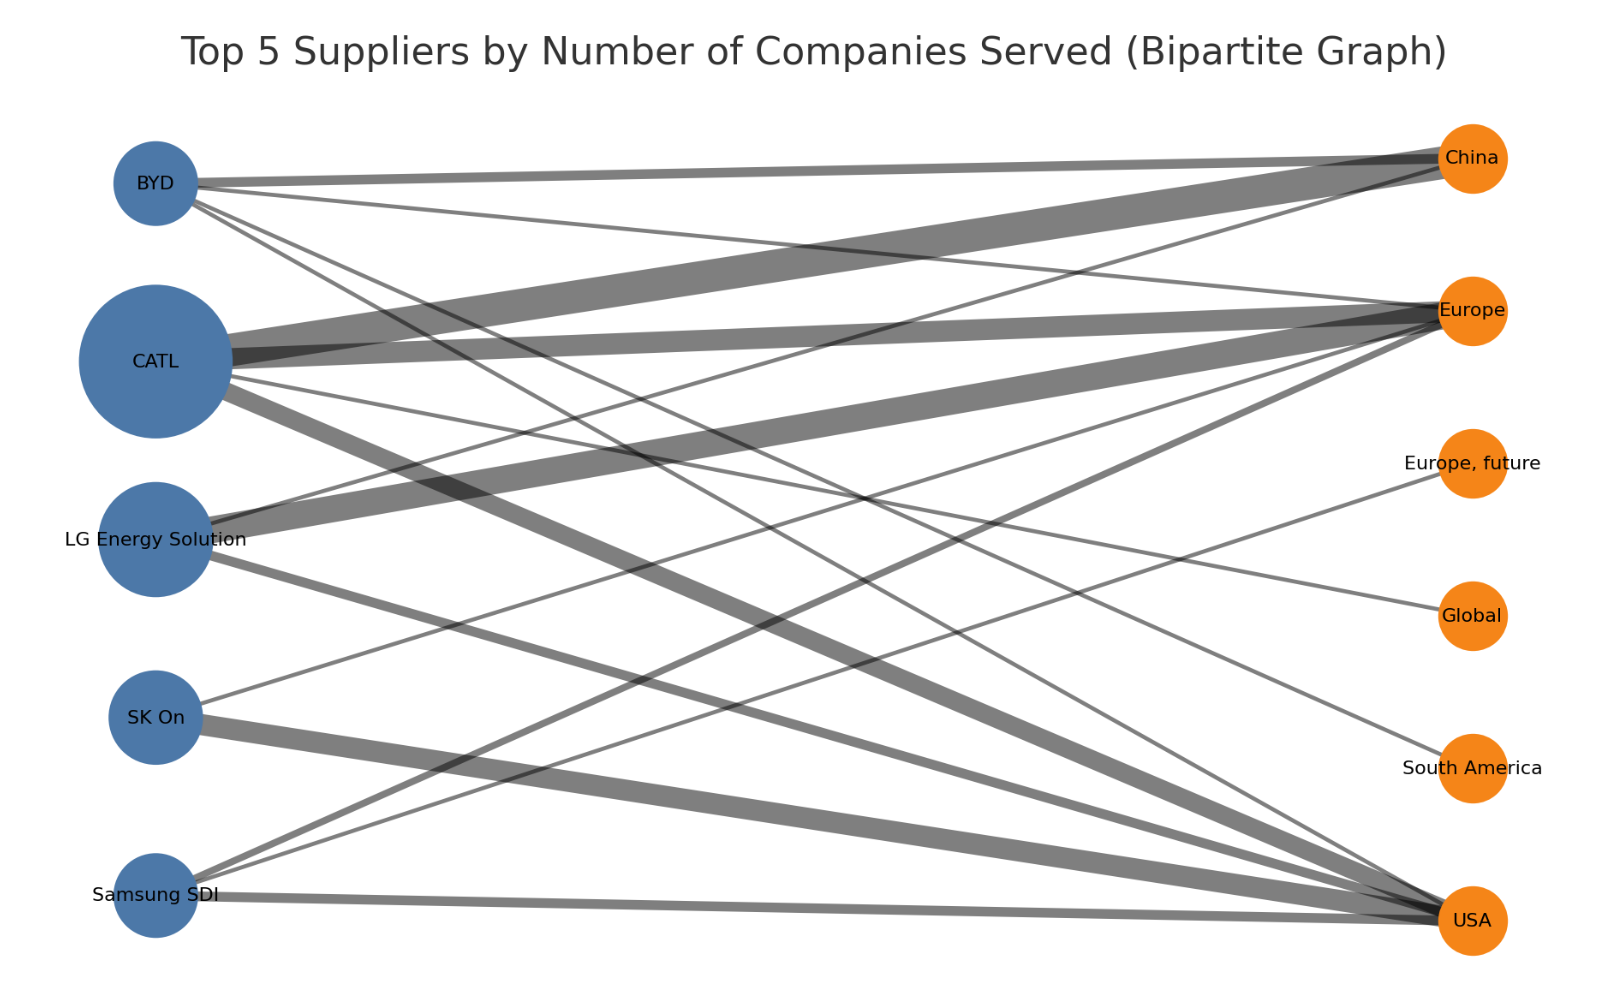

这是世界电车部件供应商前5.粗细代表供给的公司数量。圆圈代表总数。不难发现大部分产品公司都主要提供电池服务。所以我们不难得出绝大多数的电车公司都依赖外来的电池供应商。

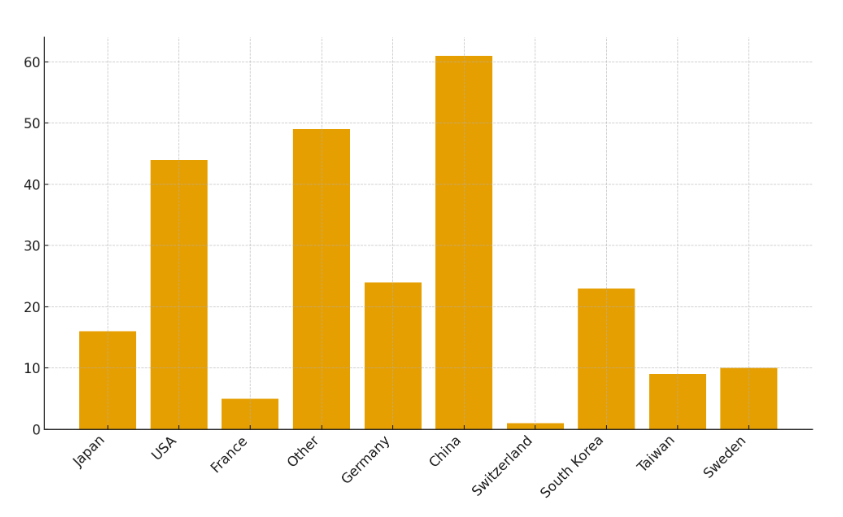
